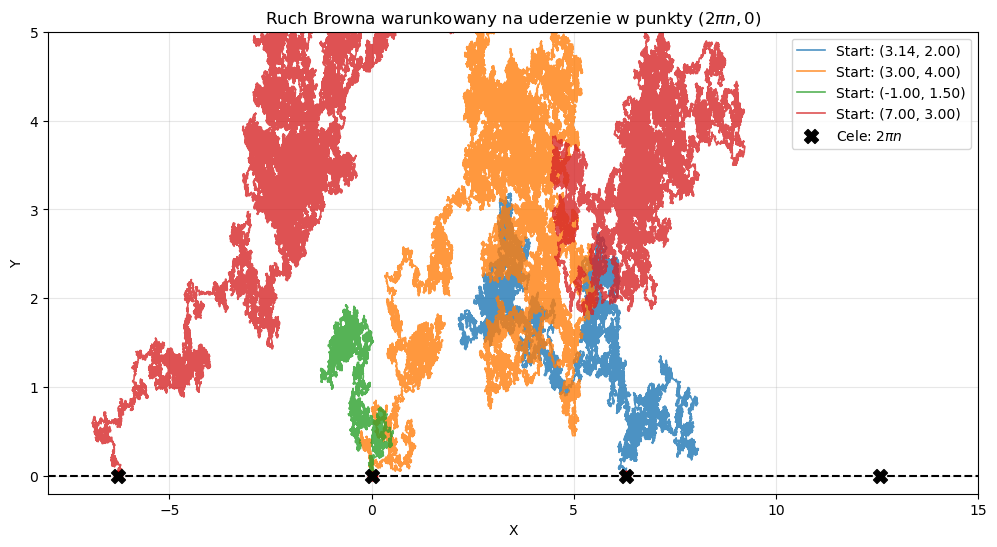

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_doob_brownian_motion(x0, y0, dt=1e-4, eps=1e-2, max_steps=1000000):
    """
    Symuluje ścieżkę 2D ruchu Browna warunkowanego na uderzenie 
    w punkty (2*pi*n, 0) na półpłaszczyźnie y > 0.
    """
    x, y = x0, y0
    path_x, path_y = [x], [y]
    
    sqrt_dt = np.sqrt(dt)
    
    for _ in range(max_steps):
        if y < eps:
            break
            
        # Zabezpieczenie przed overflow dla bardzo dużych y
        # Dla dużych y, cosh(y) ~ sinh(y), a dryf szybko maleje do 0.
        y_safe = min(y, 50.0) 
        
        cosh_y = np.cosh(y_safe)
        sinh_y = np.sinh(y_safe)
        cos_x = np.cos(x)
        sin_x = np.sin(x)
        
        denom = cosh_y - cos_x
        
        # Obliczanie dryfu (nabla log h)
        drift_x = -sin_x / denom
        drift_y = (1.0 - cosh_y * cos_x) / (sinh_y * denom)
        
        # Schemat Eulera-Maruyamy
        x += drift_x * dt + np.random.normal(0, sqrt_dt)
        y += drift_y * dt + np.random.normal(0, sqrt_dt)
        
        path_x.append(x)
        path_y.append(y)
        
    return np.array(path_x), np.array(path_y)

# ==========================================
# Konfiguracja symulacji i wizualizacja
# ==========================================
np.random.seed(42) # Dla powtarzalności
plt.figure(figsize=(12, 6))

# Symulujemy kilka ścieżek z różnych punktów startowych
start_points = [(np.pi, 2.0), (3, 4.0), (-1.0, 1.5), (7.0, 3.0)]

for idx, (x0, y0) in enumerate(start_points):
    px, py = simulate_doob_brownian_motion(x0, y0)
    plt.plot(px, py, alpha=0.8, linewidth=1.2, label=f'Start: ({x0:.2f}, {y0:.2f})')
    # Oznaczamy punkt końcowy
    plt.scatter(px[-1], py[-1], color='red', zorder=5)

# Rysowanie punktów docelowych 2*pi*n
n_vals = np.arange(-2, 4)
target_x = 2 * np.pi * n_vals
plt.scatter(target_x, np.zeros_like(target_x), color='black', marker='X', s=100, 
            label='Cele: $2\pi n$', zorder=5)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title("Ruch Browna warunkowany na uderzenie w punkty $(2\pi n, 0)$")
plt.xlabel("X")
plt.ylabel("Y")
plt.ylim(-0.2, 5)
plt.xlim(-8, 15)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

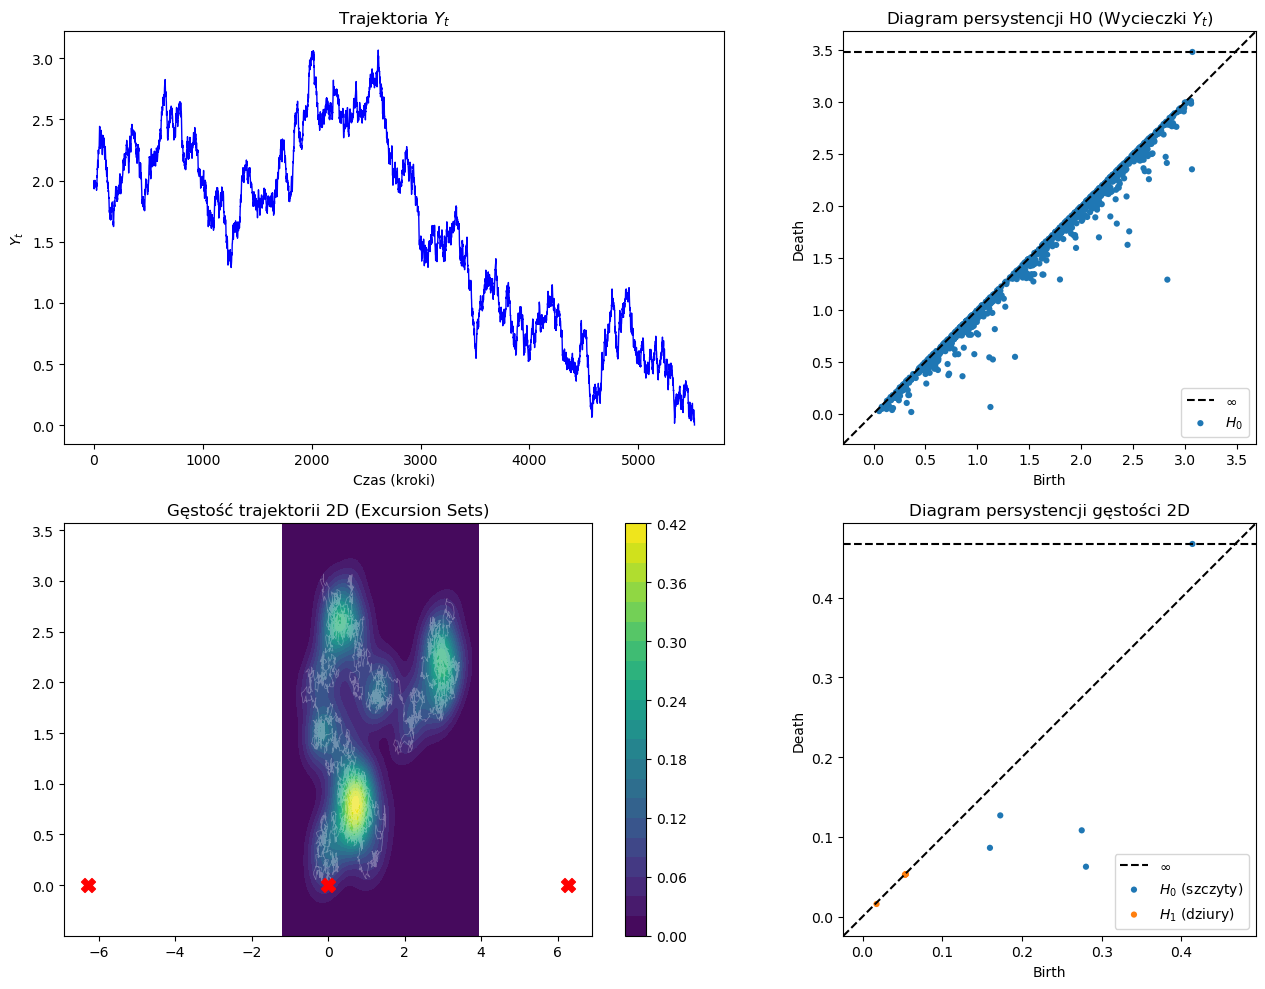

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi
from scipy.stats import gaussian_kde
from persim import plot_diagrams

# ==========================================
# 1. Funkcja symulacji (z poprzedniego kroku)
# ==========================================
def simulate_doob_brownian_motion(x0, y0, dt=1e-3, eps=1e-2, max_steps=50000):
    x, y = x0, y0
    path_x, path_y = [x], [y]
    sqrt_dt = np.sqrt(dt)
    
    for _ in range(max_steps):
        if y < eps: break
        y_safe = min(y, 50.0) 
        cosh_y, sinh_y = np.cosh(y_safe), np.sinh(y_safe)
        cos_x, sin_x = np.cos(x), np.sin(x)
        
        denom = cosh_y - cos_x
        drift_x = -sin_x / denom
        drift_y = (1.0 - cosh_y * cos_x) / (sinh_y * denom)
        
        x += drift_x * dt + np.random.normal(0, sqrt_dt)
        y += drift_y * dt + np.random.normal(0, sqrt_dt)
        
        path_x.append(x)
        path_y.append(y)
        
    return np.array(path_x), np.array(path_y)

# np.random.seed(42)
px, py = simulate_doob_brownian_motion(np.pi, 2.0, max_steps=20000)

# ==========================================
# 2. Persystencja 1D: Excursion sets dla Y_t
# ==========================================
# GUDHI domyślnie bada sublevel sets. Aby zbadać superlevel sets (excursions), 
# odwracamy znak: f(t) = -Y_t
neg_y = -py
cubical_complex_1d = gudhi.CubicalComplex(vertices=neg_y)
diag_1d = cubical_complex_1d.persistence()

# Filtrujemy tylko zerowymiarową homologię (H0), bo w 1D tylko ona istnieje
h0_1d = np.array([p[1] for p in diag_1d if p[0] == 0])

# Przywracamy oryginalne wartości Y (odwracamy znak z powrotem)
# Punkt narodzi się przy wyższym Y i umrze przy niższym
excursions_h0 = np.array([(-b, -d) for b, d in h0_1d])

# ==========================================
# 3. Persystencja 2D: Excursion sets gęstości
# ==========================================
# Tworzymy siatkę dla estymacji gęstości KDE
grid_size = 64
x_grid = np.linspace(min(px)-0.5, max(px)+0.5, grid_size)
y_grid = np.linspace(min(py)-0.5, max(py)+0.5, grid_size)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([px, py])

kde = gaussian_kde(values)
Z = np.reshape(kde(positions).T, X.shape)

# Aby szukać persystencji wycieczek (szczytów gęstości), również odwracamy znak
Z_neg = -Z
cubical_complex_2d = gudhi.CubicalComplex(
    dimensions=[grid_size, grid_size], 
    top_dimensional_cells=Z_neg.ravel()
)
diag_2d = cubical_complex_2d.persistence()

# Przetwarzamy wyniki do oryginalnych wartości gęstości
h0_2d = np.array([(-p[1][0], -p[1][1]) for p in diag_2d if p[0] == 0])
h1_2d = np.array([(-p[1][0], -p[1][1]) for p in diag_2d if p[0] == 1])

# ==========================================
# 4. Wizualizacja
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# A. Trajektoria 1D Y_t
axs[0, 0].plot(py, color='blue', linewidth=1)
axs[0, 0].set_title('Trajektoria $Y_t$')
axs[0, 0].set_xlabel('Czas (kroki)')
axs[0, 0].set_ylabel('$Y_t$')

# B. Diagram persystencji H0 dla Y_t
plot_diagrams(excursions_h0, ax=axs[0, 1], title="Diagram persystencji H0 (Wycieczki $Y_t$)")
# Punkty leżą pod przekątną, ponieważ (birth > death) w oryginalnych wartościach Y

# C. Mapa gęstości 2D (KDE)
c = axs[1, 0].contourf(X, Y, Z, levels=20, cmap='viridis')
axs[1, 0].plot(px, py, color='white', alpha=0.3, linewidth=0.5)
axs[1, 0].scatter(2*np.pi*np.arange(-1, 2), [0, 0, 0], color='red', marker='X', s=100, zorder=5)
axs[1, 0].set_title('Gęstość trajektorii 2D (Excursion Sets)')
fig.colorbar(c, ax=axs[1, 0])

# D. Diagram persystencji dla gęstości 2D
plot_diagrams([h0_2d, h1_2d], labels=['$H_0$ (szczyty)', '$H_1$ (dziury)'], ax=axs[1, 1])
axs[1, 1].set_title('Diagram persystencji gęstości 2D')

plt.tight_layout()
plt.show()

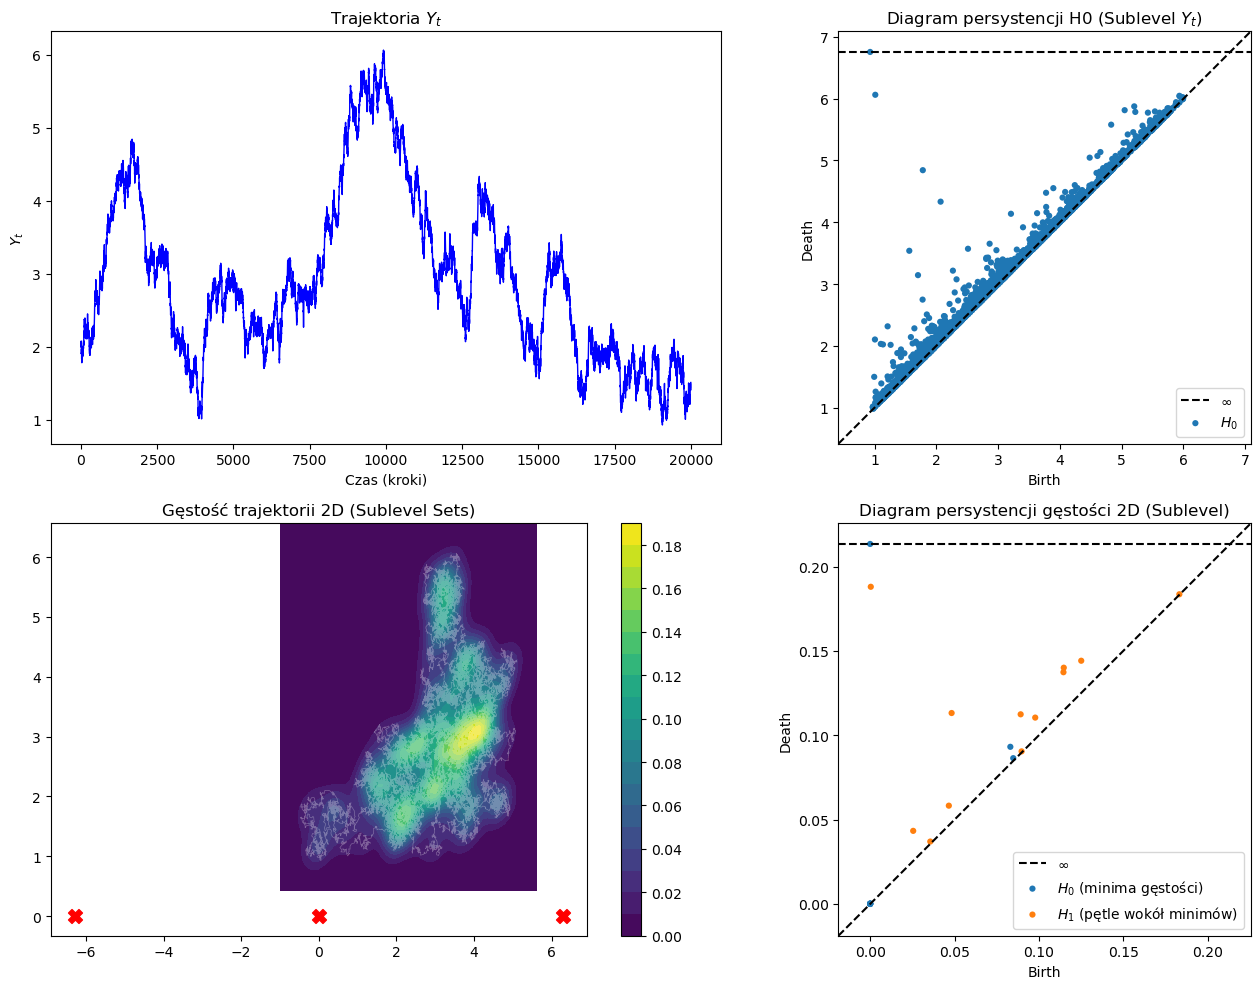

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi
from scipy.stats import gaussian_kde
from persim import plot_diagrams

# ==========================================
# 1. Funkcja symulacji
# ==========================================
def simulate_doob_brownian_motion(x0, y0, dt=1e-3, eps=1e-2, max_steps=50000):
    x, y = x0, y0
    path_x, path_y = [x], [y]
    sqrt_dt = np.sqrt(dt)
    
    for _ in range(max_steps):
        if y < eps: break
        y_safe = min(y, 50.0) 
        cosh_y, sinh_y = np.cosh(y_safe), np.sinh(y_safe)
        cos_x, sin_x = np.cos(x), np.sin(x)
        
        denom = cosh_y - cos_x
        drift_x = -sin_x / denom
        drift_y = (1.0 - cosh_y * cos_x) / (sinh_y * denom)
        
        x += drift_x * dt + np.random.normal(0, sqrt_dt)
        y += drift_y * dt + np.random.normal(0, sqrt_dt)
        
        path_x.append(x)
        path_y.append(y)
        
    return np.array(path_x), np.array(path_y)

np.random.seed(42)
px, py = simulate_doob_brownian_motion(np.pi, 2.0, max_steps=20000)

# ==========================================
# 2. Persystencja 1D: Sublevel sets dla Y_t
# ==========================================
# GUDHI domyślnie analizuje sublevel sets, więc przekazujemy po prostu Y
cubical_complex_1d = gudhi.CubicalComplex(vertices=py)
diag_1d = cubical_complex_1d.persistence()

# Filtrujemy tylko H0. Wartości b i d są od razu poprawne (b < d)
h0_1d = np.array([p[1] for p in diag_1d if p[0] == 0])

# ==========================================
# 3. Persystencja 2D: Sublevel sets gęstości
# ==========================================
grid_size = 64
x_grid = np.linspace(min(px)-0.5, max(px)+0.5, grid_size)
y_grid = np.linspace(min(py)-0.5, max(py)+0.5, grid_size)
X, Y = np.meshgrid(x_grid, y_grid)
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([px, py])

kde = gaussian_kde(values)
Z = np.reshape(kde(positions).T, X.shape)

# Przekazujemy surową gęstość Z
cubical_complex_2d = gudhi.CubicalComplex(
    dimensions=[grid_size, grid_size], 
    top_dimensional_cells=Z.ravel()
)
diag_2d = cubical_complex_2d.persistence()

# Wartości persystencji są gotowe do rysowania
h0_2d = np.array([p[1] for p in diag_2d if p[0] == 0])
h1_2d = np.array([p[1] for p in diag_2d if p[0] == 1])

# ==========================================
# 4. Wizualizacja
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# A. Trajektoria 1D Y_t
axs[0, 0].plot(py, color='blue', linewidth=1)
axs[0, 0].set_title('Trajektoria $Y_t$')
axs[0, 0].set_xlabel('Czas (kroki)')
axs[0, 0].set_ylabel('$Y_t$')

# B. Diagram persystencji H0 dla Y_t
plot_diagrams(h0_1d, ax=axs[0, 1], title="Diagram persystencji H0 (Sublevel $Y_t$)")
# Teraz punkty leżą nad przekątną!

# C. Mapa gęstości 2D (KDE)
c = axs[1, 0].contourf(X, Y, Z, levels=20, cmap='viridis')
axs[1, 0].plot(px, py, color='white', alpha=0.3, linewidth=0.5)
axs[1, 0].scatter(2*np.pi*np.arange(-1, 2), [0, 0, 0], color='red', marker='X', s=100, zorder=5)
axs[1, 0].set_title('Gęstość trajektorii 2D (Sublevel Sets)')
fig.colorbar(c, ax=axs[1, 0])

# D. Diagram persystencji dla gęstości 2D
plot_diagrams([h0_2d, h1_2d], labels=['$H_0$ (minima gęstości)', '$H_1$ (pętle wokół minimów)'], ax=axs[1, 1])
axs[1, 1].set_title('Diagram persystencji gęstości 2D (Sublevel)')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

def simulate_h1_periodic(x0, y0, dt=1e-4, eps=1e-2, max_steps=50000):
    """Twój oryginalny proces - cel: 2*pi*n"""
    x, y = x0, y0
    path = [(x, y)]
    sqrt_dt = np.sqrt(dt)
    
    for _ in range(max_steps):
        if y < eps: break
        y_safe = min(y, 50.0)
        denom = np.cosh(y_safe) - np.cos(x)
        
        drift_x = -np.sin(x) / denom
        drift_y = (1.0 - np.cosh(y_safe) * np.cos(x)) / (np.sinh(y_safe) * denom)
        
        x += drift_x * dt + np.random.normal(0, sqrt_dt)
        y += drift_y * dt + np.random.normal(0, sqrt_dt)
        path.append((x, y))
        
    return np.array(path)

def simulate_h2_single_point(x0, y0, dt=1e-4, eps=1e-2, max_steps=50000):
    """Proces warunkowany na uderzenie ściśle w (0,0) przy użyciu jądra Poissona"""
    x, y = x0, y0
    path = [(x, y)]
    sqrt_dt = np.sqrt(dt)
    
    for _ in range(max_steps):
        if y < eps: break
        r2 = x**2 + y**2
        
        # Dryf z gradientu logarytmu funkcji h(x,y) = y / (x^2 + y^2)
        drift_x = -2 * x / r2
        drift_y = (x**2 - y**2) / (y * r2)
        
        x += drift_x * dt + np.random.normal(0, sqrt_dt)
        y += drift_y * dt + np.random.normal(0, sqrt_dt)
        path.append((x, y))
        
    return np.array(path)


In [ ]:

# ==========================================
# 1. Symulacja trajektorii i filtrowanie
# ==========================================
np.random.seed(42)

# Startujemy z punktu stosunkowo blisko (0,0), żeby zbadać lokalne zachowanie
start_pt = (0.5, 0.5)

path1 = simulate_h1_periodic(*start_pt)
path2 = simulate_h2_single_point(*start_pt)

# Filtrujemy tylko punkty bardzo blisko osi Y (np. y < 0.2)
threshold_y = 0.2
cloud1 = path1[path1[:, 1] < threshold_y]
cloud2 = path2[path2[:, 1] < threshold_y]

# Podpróbkowanie (bierzemy co n-ty punkt), żeby Ripser nie wybuchł
subsample_rate1 = max(1, len(cloud1) // 400)
subsample_rate2 = max(1, len(cloud2) // 400)

cloud1_sub = cloud1[::subsample_rate1]
cloud2_sub = cloud2[::subsample_rate2]

# ==========================================
# 2. Obliczanie homologii permanentnych
# ==========================================
# maxdim=1 oznacza, że liczymy H0 (spójne składowe) i H1 (pętle/cykle)
res1 = ripser(cloud1_sub, maxdim=1)
res2 = ripser(cloud2_sub, maxdim=1)

# ==========================================
# 3. Wizualizacja
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Wykresy punktów
axs[0, 0].scatter(cloud1_sub[:, 0], cloud1_sub[:, 1], s=5, alpha=0.6, c='blue')
axs[0, 0].set_title(f"Chmura punktów h1 (Okresowe cele)\nPunkty blisko zera (N={len(cloud1_sub)})")
axs[0, 0].set_xlim(-0.2, 0.6); axs[0, 0].set_ylim(0, 0.25)

axs[0, 1].scatter(cloud2_sub[:, 0], cloud2_sub[:, 1], s=5, alpha=0.6, c='green')
axs[0, 1].set_title(f"Chmura punktów h2 (Cel: tylko (0,0))\nPunkty blisko zera (N={len(cloud2_sub)})")
axs[0, 1].set_xlim(-0.2, 0.6); axs[0, 1].set_ylim(0, 0.25)

# Diagramy persystencji
plot_diagrams(res1['dgms'], show=False, ax=axs[1, 0])
axs[1, 0].set_title("Diagram persystencji dla h1")

plot_diagrams(res2['dgms'], show=False, ax=axs[1, 1])
axs[1, 1].set_title("Diagram persystencji dla h2")

plt.tight_layout()
plt.show()

Generowanie 500 ścieżek dla h1...


KeyboardInterrupt: 

Generowanie 500 ścieżek dla h1...
Generowanie 500 ścieżek dla h2...


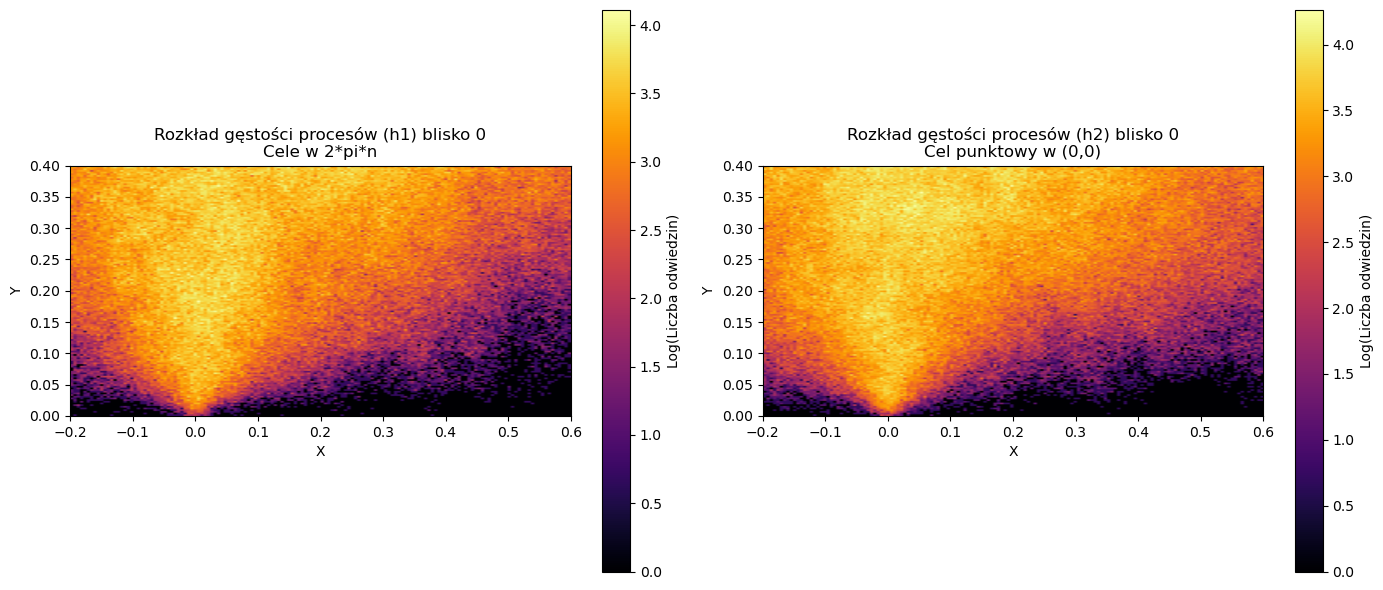

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# (Tutaj zakładamy, że funkcje simulate_h1_periodic i simulate_h2_single_point są już zdefiniowane jak wcześniej)

def simulate_monte_carlo(simulator, n_simulations, x0, y0, threshold_y=0.5):
    """Odpala symulację n razy i zbiera wszystkie punkty blisko zera."""
    all_points = []
    
    for _ in range(n_simulations):
        # Symulujemy
        path = simulator(x0, y0)
        # Bierzemy tylko końcowe fragmenty, które zeszły blisko osi X
        close_pts = path[path[:, 1] < threshold_y]
        all_points.append(close_pts)
        
    return np.vstack(all_points)

# ==========================================
# 1. Agregacja trajektorii
# ==========================================
np.random.seed(42)
N_SIMULATIONS = 500  # Odpalamy 500 razy
start_pt = (0.5, 1.0) # Startujemy z tego samego punktu

print(f"Generowanie {N_SIMULATIONS} ścieżek dla h1...")
dense_cloud_h1 = simulate_monte_carlo(simulate_h1_periodic, N_SIMULATIONS, *start_pt)

print(f"Generowanie {N_SIMULATIONS} ścieżek dla h2...")
dense_cloud_h2 = simulate_monte_carlo(simulate_h2_single_point, N_SIMULATIONS, *start_pt)

# ==========================================
# 2. Tworzenie map gęstości (Histogram 2D)
# ==========================================
# Definiujemy wspólną siatkę (grid) wokół interesującego nas punktu (0,0)
bins = 150
range_xy = [[-0.2, 0.6], [0, 0.4]]

hist_h1, xedges, yedges = np.histogram2d(
    dense_cloud_h1[:, 0], dense_cloud_h1[:, 1], bins=bins, range=range_xy
)
hist_h2, _, _ = np.histogram2d(
    dense_cloud_h2[:, 0], dense_cloud_h2[:, 1], bins=bins, range=range_xy
)

# ==========================================
# 3. Wizualizacja "ciepła" trajektorii
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Funkcja do lepszej wizualizacji logarytmicznej (żeby małe wartości nie zniknęły)
im1 = axs[0].imshow(np.log1p(hist_h1.T), origin='lower', extent=[*range_xy[0], *range_xy[1]], cmap='inferno')
axs[0].set_title("Rozkład gęstości procesów (h1) blisko 0\nCele w 2*pi*n")
axs[0].set_xlabel("X"); axs[0].set_ylabel("Y")
fig.colorbar(im1, ax=axs[0], label='Log(Liczba odwiedzin)')

im2 = axs[1].imshow(np.log1p(hist_h2.T), origin='lower', extent=[*range_xy[0], *range_xy[1]], cmap='inferno')
axs[1].set_title("Rozkład gęstości procesów (h2) blisko 0\nCel punktowy w (0,0)")
axs[1].set_xlabel("X"); axs[1].set_ylabel("Y")
fig.colorbar(im2, ax=axs[1], label='Log(Liczba odwiedzin)')

plt.tight_layout()
plt.show()